# Stock Index Performance Analysis

#### Project Overview:

This project analyzes the long-term historical performance of three major stock indices (S&P 500, NASDAQ, and Dow Jones) from 1997-present. Using Python, I retrieved live market data, calculated returns, and visualized multi-decade performance trends to identify patterns across major market cycles.

##### Section 1: Data Collection

In [1]:
import numpy as np
import pandas as pd
from pandas_datareader import data as wb
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
tickers = ['^GSPC', '^IXIC', '^DJI']
ind_data = pd.DataFrame()

for t in tickers:
    ind_data[t] = yf.download(t, start='1997-1-1', auto_adjust = False)['Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [3]:
ind_data.head()

,^GSPC,^IXIC,^DJI
Date,,,
1997-01-02,737.010010,1280.699951,6442.490234
1997-01-03,748.030029,1310.680054,6544.089844
1997-01-06,747.650024,1316.400024,6567.180176
1997-01-07,753.229980,1327.729980,6600.660156
1997-01-08,748.409973,1320.349976,6549.479980


In [4]:
ind_data.tail()

,^GSPC,^IXIC,^DJI
Date,,,
2026-05-27,7520.359863,26674.730469,50644.281250
2026-05-28,7563.629883,26917.470703,50668.968750
2026-05-29,7580.060059,26972.619141,51032.460938
2026-06-01,7599.959961,27086.810547,51078.878906
2026-06-02,7609.779785,27093.900391,51307.789062


##### Section 2: Normalized Performance Chart

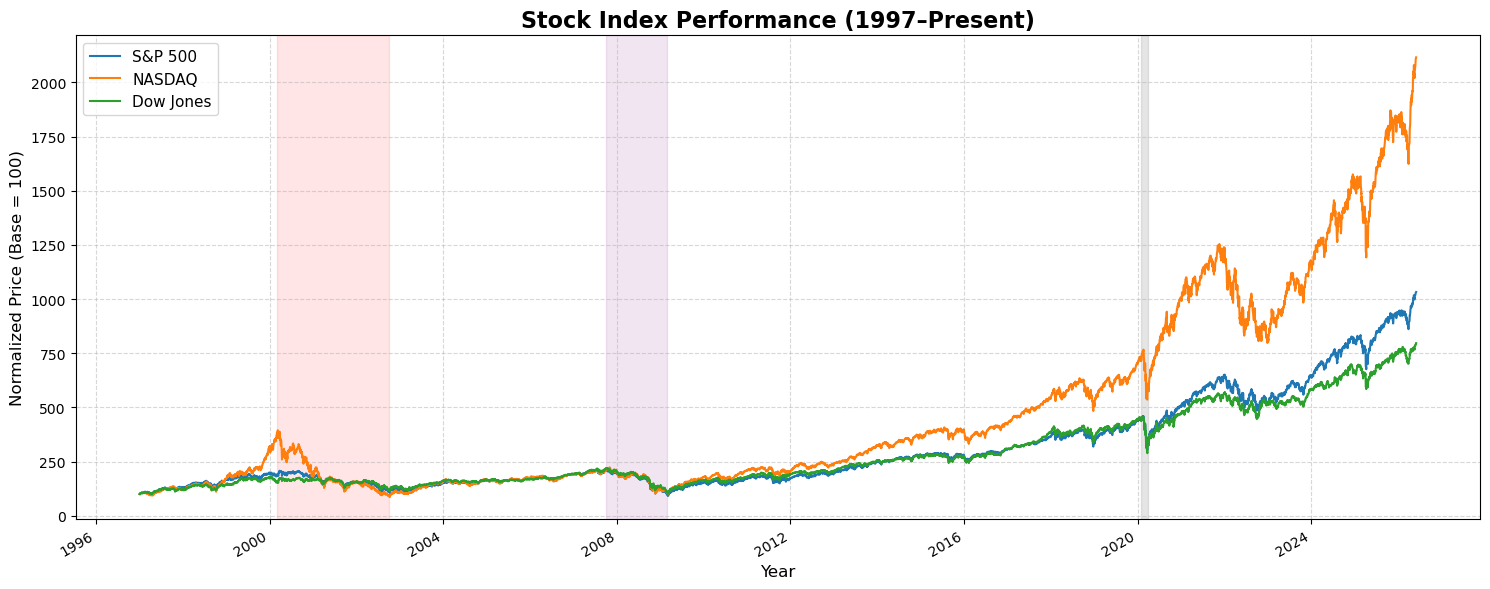

In [5]:
ax = (ind_data / ind_data.iloc[0] * 100).plot(figsize=(15, 6));

# Labels & title
ax.set_title('Stock Index Performance (1997–Present)', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Normalized Price (Base = 100)', fontsize=12)
ax.legend(['S&P 500', 'NASDAQ', 'Dow Jones'], fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)

# Major Events
ax.axvspan('2000-03-01', '2002-10-01', color='red', alpha=0.1, label='Dot-com Crash')
ax.axvspan('2007-10-01', '2009-03-01', color='purple', alpha=0.1, label='08 Financial Crisis')
ax.axvspan('2020-02-01', '2020-04-01', color='gray', alpha=0.2, label='COVID-19')

plt.tight_layout()
plt.show()

##### Section 3: Daily Returns

In [6]:
ind_returns = (ind_data / ind_data.shift(1)) - 1
ind_returns.tail()

,^GSPC,^IXIC,^DJI
Date,,,
2026-05-27,0.000165,0.000696,0.003619
2026-05-28,0.005754,0.009100,0.000487
2026-05-29,0.002172,0.002049,0.007174
2026-06-01,0.002625,0.004234,0.000910
2026-06-02,0.001292,0.000262,0.004482


##### Section 4: Annualized Returns

In [7]:
annual_ind_returns = ind_returns.mean() * 250
annual_ind_returns

^GSPC    0.097288
^IXIC    0.133602
^DJI     0.086780
dtype: float64